# FINAL REPORT ON MACHINE LEARNING 
## Unsupervised Machine Learning for Clustering Firms by Creditworthiness Based on Financial Data

## **1. Introduction**

### 1.1 Background and motivation

In recent years, the evaluation and classification of corporate creditworthiness have become increasingly important, especially in emerging markets such as Vietnam. With the rapid growth of the financial sector, the demand for data-driven methods to support risk management and decision-making has risen significantly. Traditional credit rating models are often rule-based or rely heavily on expert judgment, which can be subjective and time-consuming.

Unsupervised machine learning, especially clustering techniques, offers an alternative by automatically discovering patterns in data without predefined labels. In this study, we explore how clustering algorithms can be applied to classify the creditworthiness of non-financial firms listed on the Vietnamese stock market, using financial statement data provided by FiinGroup for the period from 2021 to 2024.

The motivation behind this research is to provide an objective and data-driven view of corporate credit risk, which can support financial institutions, investors, and policymakers in identifying groups of firms with similar risk profiles.



### 1.2 Research objectives

This project aims to:

* Apply unsupervised machine learning techniques to cluster Vietnamese non-financial firms based on their financial indicators.

* Compare the clustering performance of KMeans and Gaussian Mixture Models (GMM).

* Evaluate the interpretability and suitability of each method in the context of creditworthiness analysis.

* Propose the most appropriate model to classify firms by credit risk, supporting further credit analysis or portfolio management.

### 1.3 Research questions

The main research questions guiding this study are:

1. How effectively can unsupervised clustering algorithms identify meaningful creditworthiness groups among non-financial firms in Vietnam?

2. Between KMeans and Gaussian Mixture Models, which algorithm produces clusters that better reflect financial characteristics related to credit risk?

3. What are the strengths and limitations of each model when applied to financial statement data in the Vietnamese context?

## **2. Data**

### **2.1 Data description**

#### 2.1.1 Data source

The dataset used in this study was obtained from FiinGroup, a leading financial data and analytics provider in Vietnam. It includes standardized financial statement data of non-financial firms listed on the Ho Chi Minh Stock Exchange (HOSE), Hanoi Stock Exchange (HNX) for the period from 2021 to 2024.

The data covers annual financial reports audited and disclosed by these firms, ensuring consistency and reliability for analysis.

#### 2.1.2 Variables


The dataset used in this study covers the period from 2021 to 2024 and contains a rich set of variables designed to capture multiple dimensions of each firm's financial health and creditworthiness. Specifically, it includes:

- **Identification and time variables**:
  - *Firm code (ticker)*: unique code for each firm
  - *Company name*
  - *Year*: year of observation

- **Liquidity measures**, reflecting the firm's ability to meet short-term obligations:
  - *Current Ratio* (Current Assets / Current Liabilities)
  - *Cash Ratio* (Cash and Equivalents / Current Liabilities)

- **Solvency and leverage ratios**, indicating capital structure and debt dependency:
  - *Interest Coverage* (EBIT / Interest Expense)
  - *Debt to Asset* (Total Debt / Total Assets)
  - *Equity Ratio* (Total Equity / Total Assets)

- **Profitability indicators**, measuring the firm’s efficiency in generating profits:
  - *Return on Assets (ROA)* (Net Income / Total Assets)
  - *Return on Equity (ROE)* (Net Income / Total Equity)
  - *Net Profit Margin* (Net Income / Total Revenue)
  - *Operating Profit Margin* (Operating Income / Total Revenue)
  - *Gross Profit Margin* ((Revenue – COGS) / Revenue)
  - *EPS* (Earnings Per Share)

- **Efficiency ratios**, showing how effectively the firm uses its assets:
  - *Total Asset Turnover* (Revenue / Total Assets)
  - *AR Turnover* (Revenue / Average Accounts Receivable)

- **Cash flow and liquidity dynamics**:
  - *Cash Flow to Sales* (Operating Cash Flow / Sales)
  - *Net Increase in Cash* (change in cash balance during the year)

- **Growth measures**, reflecting the firm's expansion over time:
  - *Revenue Growth* (annual % growth in revenue)
  - *Net Income Growth* (annual % growth in net income)
  - *Asset Growth* (annual % growth in total assets)

- **Asset structure and capital structure details**:
  - *Fixed Asset Ratio* (Fixed Assets / Total Assets)
  - *Equity to Fixed Asset Ratio* (Equity / Fixed Assets)

Together, these variables provide a multi-dimensional view of each firm’s financial position, covering aspects of liquidity, solvency, profitability, efficiency, growth, and capital allocation. By using these indicators as input features for clustering, the study aims to uncover natural groupings of firms with similar financial profiles, thereby supporting objective and data-driven assessment of creditworthiness.


#### 2.1.3 Number of firms and coverage

The dataset used in this study comprises financial data of non-financial listed firms in Vietnam across four consecutive years from 2021 to 2024. Specifically, the number of firms included in the analysis for each year is as follows:

* 2021: 509 firms

* 2022: 507 firms

* 2023: 469 firms

* 2024: 477 firms

Overall, the dataset captures a relatively stable and broad coverage of the Vietnamese non-financial corporate sector during this period. Although the number of firms slightly decreased from 509 in 2021 to 469 in 2023, there is a modest recovery to 477 firms in 2024. This fluctuation may reflect firm delistings, new listings, or temporary data unavailability due to missing or incomplete reports.

In percentage terms, the dataset covers approximately:

Over 97% of firms between 2021 and 2022,

Around 90% in 2023,

Rising again to 93–94% in 2024, compared to the total universe of non-financial listed companies on the Ho Chi Minh City Stock Exchange (HOSE) and Hanoi Stock Exchange (HNX).

These figures suggest that the dataset provides a comprehensive and representative view of the non-financial corporate landscape in Vietnam, ensuring sufficient sample size and diversity for subsequent statistical analyses, clustering, and modeling.

### **2.2 Data preprocessing**

#### 2.2.1 Data preprocessing

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

In [2]:
# Load data
df = pd.read_excel('data.xlsx')

In [3]:
df

,Mã,Tên công ty,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,...,Total Asset Turnover,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash
0,HU1,Xây dựng HUD1,2024,1.037184,0.111816,0.481505,0.783742,0.216258,0.004555,0.021064,...,0.290804,0.497199,0.353162,0.080736,455390.536232,0.082914,0.006360,34.001469,306.0,50.325811
1,VIT,Viglacera Tiên Sơn,2024,0.964740,0.082045,1.679214,0.701896,0.298104,0.024789,0.083156,...,1.013189,33.190604,0.147653,0.072523,613.237907,-0.063850,0.521886,0.571204,1049.0,59.114421
2,HTP,In SGK Hòa Phát,2021,3.442066,0.256280,1.044614,0.570658,0.429342,0.010236,0.023842,...,0.004379,0.035018,-39.625608,1.990419,337.332344,261.335454,0.001143,375.549708,613.0,86.308370
3,VLA,PT Công nghệ Văn Lang,2021,3.687171,0.064932,2446.284399,0.179302,0.820698,0.224377,0.273398,...,0.572213,3.211926,-0.346444,0.855762,324.193130,0.594209,0.227752,3.603475,5247.0,-1.626315
4,TTF,Gỗ Trường Thành,2023,1.199646,0.094166,0.376696,0.906285,0.093715,-0.050605,-0.539988,...,0.547445,1.835746,0.024350,-0.220263,116.312913,-0.051764,0.121092,0.773912,-325.0,-26.706777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1957,L61,LILAMA 69-1,2022,1.005570,0.001892,-1.381310,0.899151,0.100849,-0.101374,-1.005205,...,0.564371,3.081877,-0.047460,-0.380373,-199.899668,-0.104975,0.081945,1.230690,-9765.0,-17.010827
1958,TXM,Thạch cao Xi măng,2023,5.502630,0.204826,-3.922772,0.181080,0.818920,-0.034472,-0.042094,...,0.819651,0.864370,0.171324,-0.560350,-264.746497,-0.312329,0.003403,240.652238,-667.0,0.467287
1959,VHL,Viglacera Hạ Long,2023,1.785775,0.156505,-5.022684,0.356840,0.643160,-0.082946,-0.128966,...,1.467576,36.572287,0.042124,-0.242649,-410.106307,-0.183962,0.376766,1.707055,-2780.0,8.345142
1960,TNI,Tập đoàn Thành Nam,2021,1.894262,0.017042,1.004440,0.514052,0.485948,-0.060710,-0.124931,...,1.771543,3.345429,-0.050301,0.310142,-580.216037,-0.007049,0.003190,152.316378,-1244.0,-0.031321


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1962 entries, 0 to 1961
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Mã                           1962 non-null   object 
 1   Tên công ty                  1962 non-null   object 
 2   Năm                          1962 non-null   int64  
 3   Current Ratio                1962 non-null   float64
 4   Cash Ratio                   1962 non-null   float64
 5   Interest Coverage            1962 non-null   float64
 6   Debt to Asset                1962 non-null   float64
 7   Equity Ratio                 1962 non-null   float64
 8   ROA                          1962 non-null   float64
 9   ROE                          1962 non-null   float64
 10  Net Profit Margin            1962 non-null   float64
 11  Operating Profit Margin      1962 non-null   float64
 12  Gross Profit Margin          1962 non-null   float64
 13  Total Asset Turnov

**a) Checking missing values**

In [5]:
# Identify numeric features only (include columns of type int, float)
numeric_features = df.select_dtypes(include=[np.number])

# Remove 'Năm'
numeric_features = numeric_features.drop(columns=['Năm'])

In [6]:
# Check missing values
print(numeric_features.isnull().sum())

Current Ratio                  0
Cash Ratio                     0
Interest Coverage              0
Debt to Asset                  0
Equity Ratio                   0
ROA                            0
ROE                            0
Net Profit Margin              0
Operating Profit Margin        0
Gross Profit Margin            0
Total Asset Turnover           0
AR Turnover                    0
Cash Flow to Sales             0
Revenue Growth                 0
Net Income Growth              0
Asset Growth                   0
Fixed Asset Ratio              0
Equity to Fixed Asset Ratio    0
EPS                            0
Net Increase in Cash           0
dtype: int64


**b) Checking Outlier**

In [7]:
numeric_features.describe()

,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,Gross Profit Margin,Total Asset Turnover,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash
count,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000
mean,2.214001,0.317595,305.179802,0.484580,0.515458,0.046517,0.054333,0.262069,0.247125,0.172501,1.282803,10.074020,-1.825271,0.285594,231.419261,0.224347,0.230352,53.475494,1760.691641,47.524262
std,3.053448,0.599538,4360.850469,0.217812,0.217872,0.071142,0.690929,11.462018,11.055957,0.173077,1.519399,21.394855,79.493456,5.088646,10281.068051,5.911190,0.204890,722.477801,3466.448145,760.612031
min,0.130935,0.000038,-2600.703867,0.012994,-0.375716,-0.510247,-25.331414,-95.098269,-118.159602,-3.122615,-0.001076,-0.007707,-3519.810367,-116.435640,-1248.385703,-0.748568,0.000017,-19.259452,-13813.000000,-14146.786642
25%,1.151980,0.056243,1.626720,0.319829,0.346634,0.010710,0.026990,0.010041,0.011195,0.075931,0.507548,2.037825,-0.025223,-0.099620,-0.437588,-0.046231,0.073427,1.475650,260.000000,-15.511642
50%,1.477656,0.149911,3.843120,0.476940,0.523060,0.034224,0.074979,0.034625,0.040321,0.137374,0.948080,4.699886,0.045071,0.063006,0.005388,0.038354,0.170331,2.764980,1034.500000,1.281977
75%,2.249974,0.374944,15.505629,0.653366,0.680171,0.075467,0.141628,0.089014,0.103060,0.234893,1.491371,9.355534,0.138481,0.243059,0.410270,0.153092,0.324895,6.288076,2427.750000,34.010771
max,62.702583,11.148734,116687.872575,1.375716,0.987006,0.473094,1.358064,498.393185,474.901490,1.000000,13.915240,315.986118,15.234814,152.539202,455390.536232,261.335454,0.952768,24774.121744,53423.000000,14583.380000


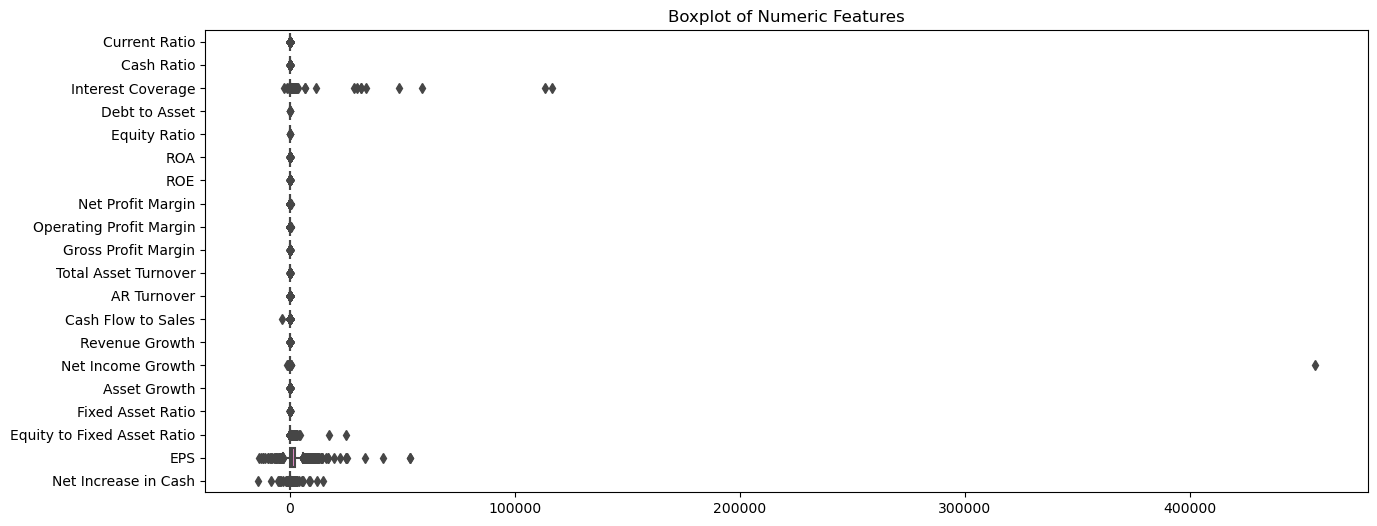

In [8]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=numeric_features, orient="h")
plt.title("Boxplot of Numeric Features")
plt.show()

In [9]:
outlier_counts = {}

for col in numeric_features.columns:
    Q1 = numeric_features[col].quantile(0.25)
    Q3 = numeric_features[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    count = ((numeric_features[col] < lower_bound) | (numeric_features[col] > upper_bound)).sum()
    outlier_counts[col] = count

outlier_counts = pd.Series(outlier_counts)
print(outlier_counts)

Current Ratio                  186
Cash Ratio                     147
Interest Coverage              310
Debt to Asset                    6
Equity Ratio                     6
ROA                            139
ROE                            130
Net Profit Margin              238
Operating Profit Margin        225
Gross Profit Margin            127
Total Asset Turnover           125
AR Turnover                    199
Cash Flow to Sales             249
Revenue Growth                 165
Net Income Growth              312
Asset Growth                   156
Fixed Asset Ratio               83
Equity to Fixed Asset Ratio    271
EPS                            169
Net Increase in Cash           459
dtype: int64


**c) Visualize correlation heatmap**

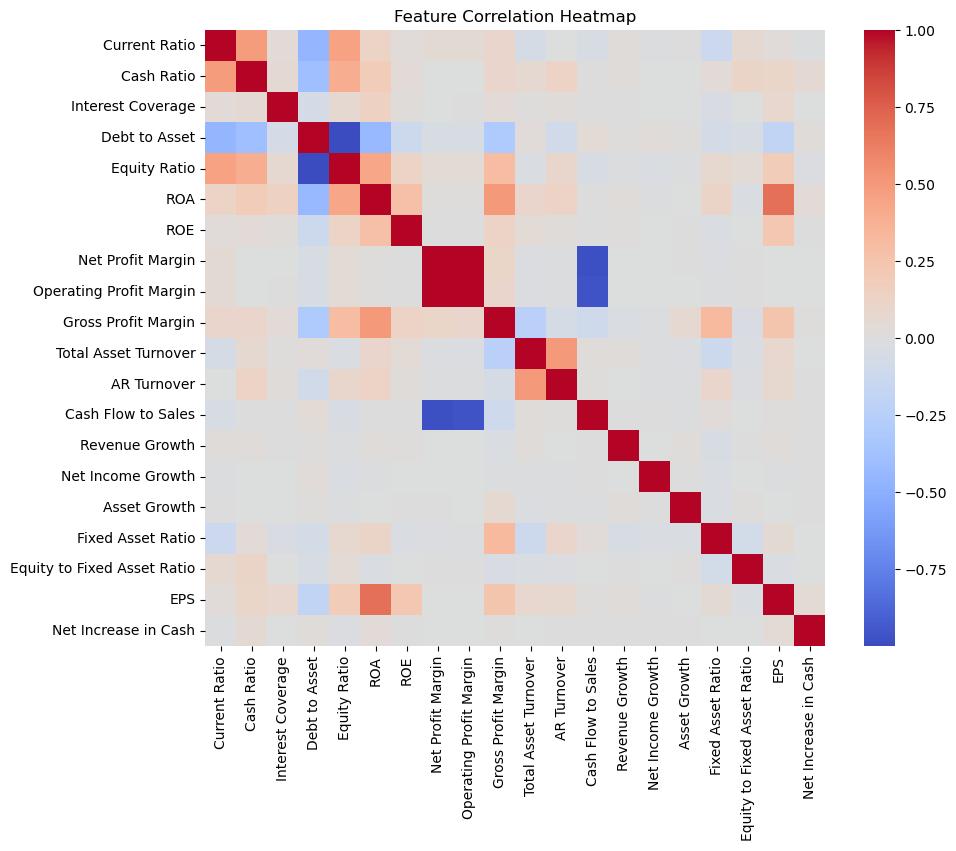

In [10]:
plt.figure(figsize=(10,8))
corr_matrix = pd.DataFrame(df, columns=numeric_features.columns).corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

**d) Handling outliers**

In [11]:
from scipy.stats.mstats import winsorize

# Apply Winsorization to limit extreme outliers (1% lower and upper tails)
df_winsor = numeric_features.apply(lambda x: winsorize(x, limits=[0.01, 0.01]))

# Apply RobustScaler to reduce the effect of remaining outliers
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
numeric_scaled = scaler.fit_transform(df_winsor)

# Convert back to DataFrame with original column names
numeric_scaled_df = pd.DataFrame(numeric_scaled, columns=numeric_features.columns)

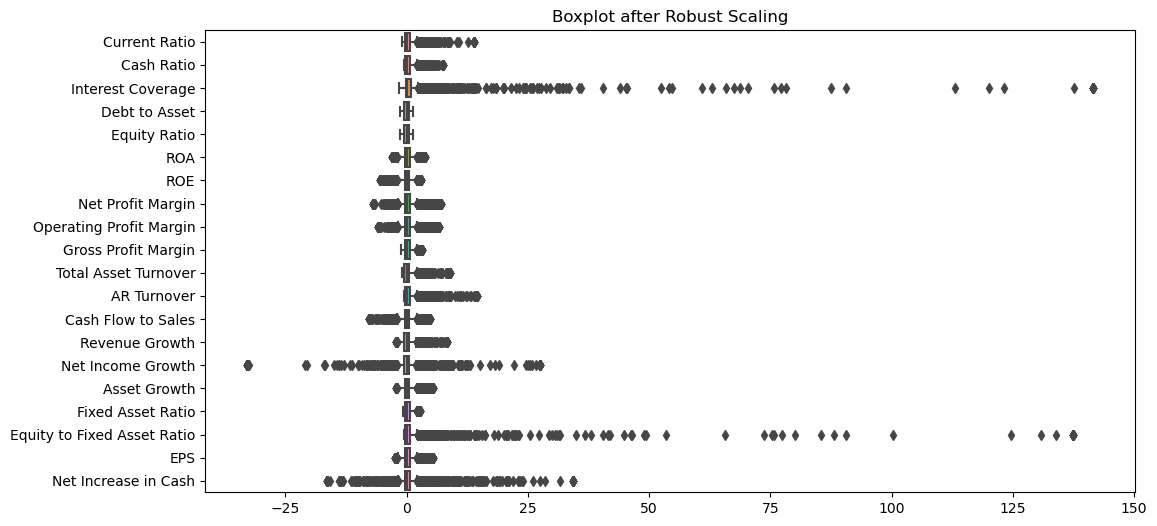

In [57]:
plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_scaled_df, orient='h')
plt.title('Boxplot after Robust Scaling')
plt.show()

**e) PCA**

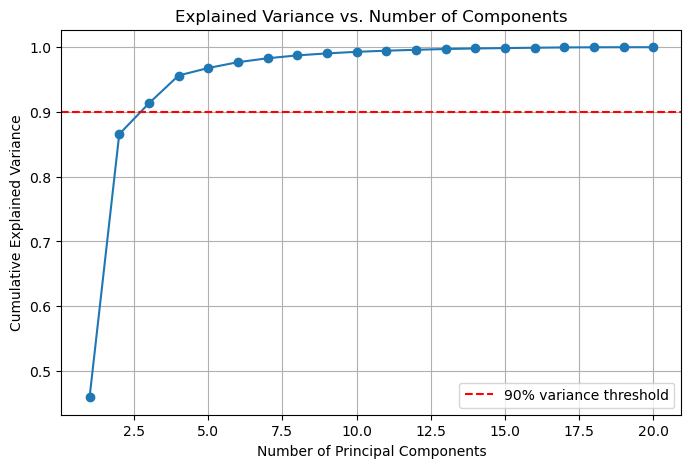

Selected number of components: 3


In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA on scaled data
pca = PCA().fit(numeric_scaled_df)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance vs number of components
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.legend()
plt.grid(True)
plt.show()

# Determine number of components to reach ≥90% variance
n_components = np.argmax(cumulative_variance >= 0.9) + 1
print(f"Selected number of components: {n_components}")

In [13]:
# Apply PCA with chosen number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(numeric_scaled_df)

# Convert to DataFrame for easier use later
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])

In [14]:
print(pca_df.head())

          PC1        PC2        PC3
0   -1.189854   4.369306  13.643921
1   -4.765986  -1.672988  13.827478
2   36.524517  64.671092  15.605311
3  116.097332 -75.813976  12.071771
4   -4.898254  -1.404296  11.767157


## **3. Methodology**

### **3.1 Clustering algorithms**

#### 3.1.1 KMeans

KMeans is a partitional clustering algorithm that seeks to partition n observations into k clusters in which each observation belongs to the cluster with the nearest mean (centroid). The algorithm iteratively updates centroids and reassigns data points until convergence.

Mathematically, KMeans aims to minimize the within-cluster sum of squares (WCSS):

![Công thức toán học](images/311kmeans.png)

where μi is the centroid of cluster 𝐶𝑖

***Strengths:***

+ Computationally efficient (time complexity approximately O(n⋅k⋅d⋅t), with d dimensions and t iterations).

+ Simple and widely used in practice.

***Limitations:***

+ Requires the number of clusters (k) to be specified a priori.

+ Assumes spherical clusters of similar size.

+ Sensitive to initialization.

#### 3.1.2 Gaussian Mixture Model (GMM)

The Gaussian Mixture Model is a probabilistic model that represents the data as a mixture of several Gaussian distributions, each corresponding to a cluster. Instead of assigning each point to a single cluster, GMM computes membership probabilities.

The model estimates parameters using the Expectation-Maximization (EM) algorithm, which iteratively maximizes the likelihood function.

![Công thức toán học](images/312gmm.png)

where 𝜋𝑖 are the mixture weights, 𝜇𝑖 the means, and Σ𝑖 the covariance matrices.

***Strengths:***

+ Can model elliptical clusters with varying sizes and orientations.

+ Provides probabilistic cluster memberships, useful for soft clustering.

**Limitations:**

+ Requires the number of components (k) to be specified.

+ Sensitive to initialization and can converge to local optima.

### **3.2 Model selection and parameter tuning**

Selecting appropriate models and tuning their hyperparameters are critical steps in unsupervised learning, as these decisions directly impact the interpretability and validity of clustering results. To ensure methodological rigor, this study adopted well-established techniques for determining the optimal number of clusters and model parameters. The following sections describe each method, its theoretical foundation, and practical application.

#### 3.2.1 Elbow method and Silhouette Score for KMeans

* Elbow Method

The Elbow Method is one of the most common approaches to estimate the optimal number of clusters (k) in partitional clustering algorithms such as KMeans and Gaussian Mixture Models (GMM). The method involves calculating the Within-Cluster Sum of Squares (WCSS) for different values of k. The WCSS typically decreases as k increases because clusters are smaller and better fitted to the data. However, after a certain point, adding more clusters results in only marginal gains. The “elbow” point on the plot of WCSS versus k indicates the value of k beyond which the marginal gain drops sharply.

This approach is grounded in the principle of balancing model complexity and goodness-of-fit (James et al., 2013). By selecting k at the elbow, we mitigate the risk of overfitting while capturing sufficient structure in the data.

* Silhouette Score

To complement the Elbow Method, the Silhouette Score provides a quantitative validation of clustering consistency. For each observation, the Silhouette Coefficient compares the mean intra-cluster distance (cohesion) with the mean nearest-cluster distance (separation). The score ranges from -1 to 1, where higher values indicate that samples are well matched to their own cluster and poorly matched to neighboring clusters.

A high average Silhouette Score suggests that the clusters are dense and well separated, thus supporting the selection of k. This metric is especially valuable because it is independent of the method used to generate clusters.

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K_range = range(2, 10)  # Try K=2 to 9

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_df, labels))

In [16]:
# Create DataFrame to show results
kmeans_results = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores
})
print(kmeans_results)

   K        Inertia  Silhouette Score
0  2  663329.967011          0.898579
1  3  235072.677083          0.915678
2  4  182383.331589          0.813472
3  5  144652.573665          0.819409
4  6  114733.258740          0.674938
5  7   88924.315705          0.677125
6  8   73015.710089          0.682086
7  9   57823.836248          0.693279


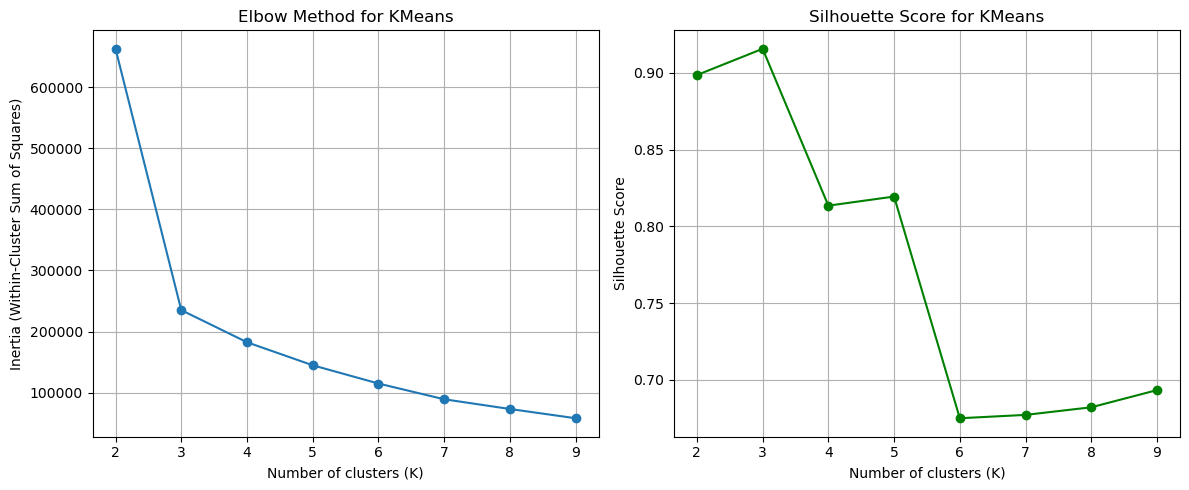

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for KMeans')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score for KMeans')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

Based on the elbow method and silhouette scores, the optimal number of clusters for KMeans appears to be **K=3**, which achieves both a significant drop in inertia and the highest silhouette score, indicating well-separated and coherent clusters

#### 3.2.2 AIC and BIC for Gaussian Mixture Models

Selecting the appropriate number of components (𝐾) in Gaussian Mixture Models (GMM) is a critical step in clustering and density estimation. Choosing too few components can lead to underfitting, missing important structure in the data, while too many components can cause overfitting, capturing random noise rather than true patterns. To address this trade-off, information criteria such as the Akaike Information Criterion (AIC) and the Bayesian Information Criterion (BIC) provide statistically grounded approaches that quantify the balance between model fit and complexity.

* **Akaike Information Criterion (AIC)**

The AIC, introduced by Akaike (1974), evaluates the relative quality of statistical models for a given dataset by combining the goodness of fit and a penalty for model complexity. The formal expression is:

![Công thức toán học](images/aic.png)

AIC tends to favor models with slightly more complexity than BIC because its penalty is lighter (2k vs. k⋅ln(n)). Lower AIC values indicate better models.

* **Bayesian Information Criterion (BIC)**

The BIC, also known as the Schwarz Information Criterion (Schwarz, 1978), is similar in spirit to AIC but imposes a stronger penalty on model complexity, especially as the sample size increases. The formula for BIC is:

![Công thức toán học](images/bic.png)

A lower BIC indicates a better trade-off between model complexity and goodness of fit (Schwarz, 1978). In practice, the number of components K corresponding to the minimum BIC value is selected as the optimal model.

In [18]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import pandas as pd

# Define the range of number of components to evaluate
n_components = range(2, 10)

# Initialize lists to store AIC and BIC values
aic_scores = []
bic_scores = []

# Fit GMM for each number of components and record the AIC and BIC
for k in n_components:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(pca_df)  
    aic_scores.append(gmm.aic(pca_df))
    bic_scores.append(gmm.bic(pca_df))

# Convert to DataFrame for easier reporting
results_df = pd.DataFrame({
    'Number of Components (K)': n_components,
    'AIC': aic_scores,
    'BIC': bic_scores
})

# Display the scores
print(results_df)

   Number of Components (K)           AIC           BIC
0                         2  29521.304174  29627.356847
1                         3  27883.597233  28045.467103
2                         4  26897.668946  27115.356011
3                         5  26452.251460  26725.755722
4                         6  25002.798053  25332.119512
5                         7  24486.459525  24871.598181
6                         8  23781.661370  24222.617222
7                         9  23505.345413  24002.118461


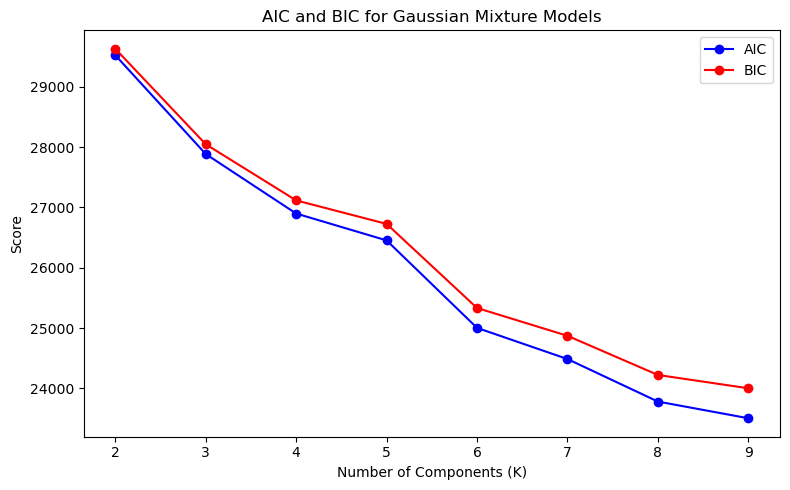

In [19]:
# Plot AIC and BIC scores
plt.figure(figsize=(8,5))
plt.plot(n_components, aic_scores, marker='o', color='blue', label='AIC')
plt.plot(n_components, bic_scores, marker='o', color='red', label='BIC')
plt.xlabel('Number of Components (K)')
plt.ylabel('Score')
plt.title('AIC and BIC for Gaussian Mixture Models')
plt.legend()
plt.tight_layout()
plt.show()

The table above shows the AIC and BIC scores for Gaussian Mixture Models with the number of components (K) ranging from 2 to 9.

Both AIC and BIC values decrease steadily as K increases, reflecting the improved fit of more complex models. However, the rate of improvement diminishes for higher K values, indicating diminishing returns.

The lowest BIC is observed at **K=9** (BIC ≈ 24,002), suggesting that this model best balances goodness of fit with complexity under BIC's stronger penalty for additional parameters.

Similarly, the lowest AIC is also at **K=9** (AIC ≈ 23,505), although AIC typically favors more complex models due to its lighter penalty.

Based on these criteria, K=9 appears to be the optimal number of components for the Gaussian Mixture Model in this dataset. This choice ensures the model captures sufficient structure in the data without overfitting.

## **4. Results**

### **4.1 Clustering results**

In [20]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

#### 4.1.1 KMeans

In [21]:
# KMeans clustering (K=3)

# Create and fit the model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pca_df)

# Add cluster labels to DataFrame for analysis or plotting
pca_df['KMeans_cluster'] = kmeans_labels

In [22]:
# Column names of first three principal components
pc1, pc2, pc3 = pca_df.columns[0], pca_df.columns[1], pca_df.columns[2]

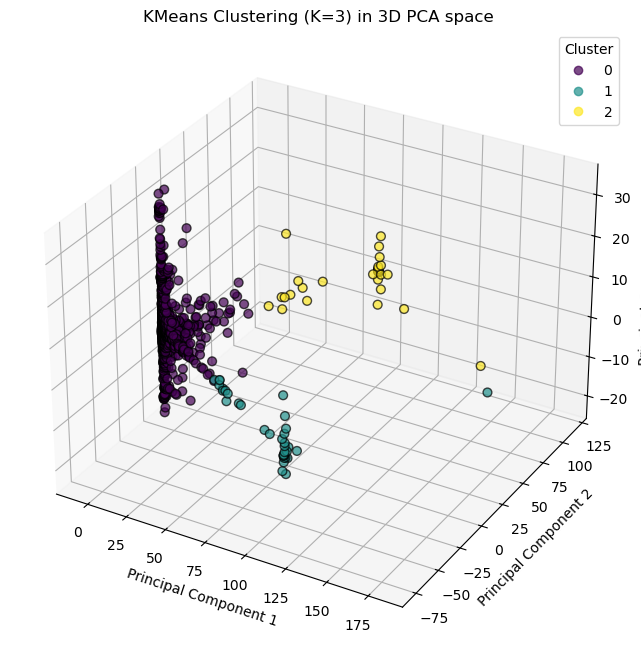

In [23]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df[pc1], pca_df[pc2], pca_df[pc3],
    c=pca_df['KMeans_cluster'],
    cmap='viridis',
    s=40,
    alpha=0.7,
    edgecolor='k'
)

ax.set_title('KMeans Clustering (K=3) in 3D PCA space')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

#### 4.1.2 Gaussian Mixture Model (GMM)

In [24]:
# Create and fit the model
gmm = GaussianMixture(n_components=9, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(pca_df.drop(columns='KMeans_cluster'))

# Add cluster labels to DataFrame
pca_df['GMM_cluster'] = gmm_labels

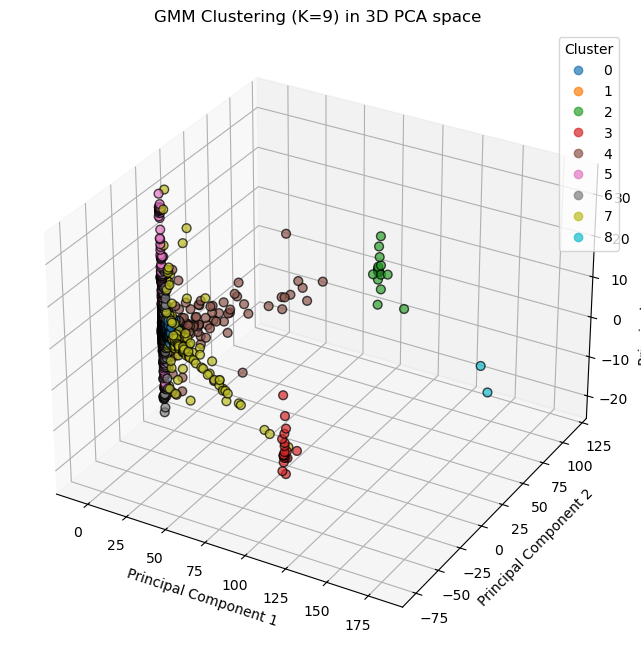

In [25]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df[pc1], pca_df[pc2], pca_df[pc3],
    c=pca_df['GMM_cluster'],
    cmap='tab10',
    s=40,
    alpha=0.7,
    edgecolor='k'
)

ax.set_title('GMM Clustering (K=9) in 3D PCA space')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

### **4.2 Analysis and justification**

In this clustering task, both KMeans and Gaussian Mixture Model (GMM) were applied after dimensionality reduction using PCA. The visualizations in the 3D PCA space provide valuable insights into the strengths and weaknesses of each method.

**1. Visual separation and cluster shape**

* KMeans with K=3 produces clear, compact, and nearly spherical clusters. This behavior is expected since KMeans partitions data by minimizing within-cluster variance, implicitly favoring isotropic (round) clusters of similar size.

* However, the GMM model with K=9 reveals a more nuanced structure in the data: clusters of varying sizes, shapes, and densities appear clearly in the PCA plot. This flexibility is due to GMM modeling each cluster as a Gaussian distribution with its own covariance, which can capture elliptical shapes and overlapping regions.

**2. Model flexibility and data complexity**

* The dataset seems to exhibit heterogeneity that cannot be adequately represented by a small number of spherical clusters. The richer structure discovered by GMM aligns better with what is observed visually: some groups are tightly packed, while others are more dispersed or elongated.

* GMM's ability to allow clusters with different orientations and variances is critical when the true underlying structure deviates from the idealized spherical clusters assumed by KMeans.

**3. Trade-off between simplicity and representativeness**

* Although KMeans with K=3 provides a simpler segmentation, it risks oversimplifying the real data structure, missing potentially meaningful subgroups.

* GMM with K=9 introduces more components, which at first glance seems complex. However, this complexity is justified: the additional components allow the model to capture subtle patterns in the data that KMeans cannot.

**4. Limitations of numerical indices**

* Internal clustering validation indices like Silhouette Score, Davies–Bouldin Index, and Calinski–Harabasz Index favor compact, well-separated clusters, thus typically score KMeans higher.

* These metrics penalize overlapping clusters or clusters with irregular shapes – exactly the cases where GMM excels.

* As such, relying solely on these scores could misrepresent the model’s ability to reflect the real structure.

Considering the visual inspection of clusters in PCA space, the flexible nature of GMM in modeling elliptical and heterogeneous clusters, and the richer structure uncovered, the GMM model (K=9) better fits the complexity of this dataset compared to KMeans (K=3). While KMeans achieves higher internal validation scores due to its preference for spherical clusters, GMM provides a segmentation that is more interpretable and aligned with the intrinsic data characteristics.

## **5. Discussion**

In [26]:
# Add cluster labels
df_with_clusters = df.copy()
df_with_clusters['GMM_cluster'] = gmm_labels

# Compute summary statistics only on numeric features
cluster_summary = df_with_clusters.groupby('GMM_cluster')[numeric_features.columns].agg(['mean', 'std', 'count'])

In [27]:
cluster_summary

Current Ratio                 Cash Ratio                  \
                     mean       std count       mean       std count   
GMM_cluster                                                            
0                3.051440  3.347379   336   0.424096  0.795948   336   
1                1.514849  1.376040   701   0.138043  0.256577   701   
2                4.123703  4.102431    21   0.918845  2.223135    21   
3                4.027242  1.687581    19   0.706582  0.514353    19   
4                3.986024  6.943404    92   0.341774  0.679199    92   
5                1.369784  0.531584   318   0.284331  0.335104   318   
6                2.222198  2.372466   357   0.423458  0.552852   357   
7                3.942580  5.972326   116   0.657669  0.936168   116   
8               20.295732  0.812420     2   0.905460  0.619942     2   

            Interest Coverage                     Debt to Asset  ...  \
                         mean           std count          mean  ...   
GMM_cluster                                                      ...   
0                   32.651072     34.287163   336      0.384678  ...   
1                    2.662310      2.442002   701      0.572878  ...   
2                   43.135290     97.126827    21      0.339865  ...   
3                28219.656372  35188.621450    19      0.245382  ...   
4                   18.720690     54.638657    92      0.425347  ...   
5                    4.364895      4.100082   318      0.575507  ...   
6                    1.273574    158.037486   357      0.424799  ...   
7                  345.017350    374.196741   116      0.295300  ...   
8                 2629.700773   1492.619636     2      0.027449  ...   

            Fixed Asset Ratio Equity to Fixed Asset Ratio                     \
                        count                        mean          std count   
GMM_cluster                                                                    
0                         336                   12.870917    10.451322   336   
1                         701                    2.762866     2.133468   701   
2                          21                 3894.938853  5933.665479    21   
3                          19                    9.219344     9.090758    19   
4                          92                  126.349589   111.277458    92   
5                         318                    1.457882     0.703549   318   
6                         357                    3.310149     2.217700   357   
7                         116                    8.460007     7.895480   116   
8                           2                 1218.892506   871.729456     2   

                     EPS                    Net Increase in Cash               \
                    mean          std count                 mean          std   
GMM_cluster                                                                     
0            2275.773810  3254.221275   336             4.095447    47.780451   
1             939.690442  1856.544275   701             1.549195    35.215072   
2             363.142857   678.968135    21            26.227004   103.026091   
3            4633.526316  4215.586836    19             5.717247   161.679180   
4             938.663043  1746.033623    92           -23.132387   145.176008   
5            1517.066038  2553.398433   318           250.813178  1799.872313   
6            2588.064426  5639.652081   357            -2.188737   341.462463   
7            3808.732759  4203.804135   116           114.649169   623.101976   
8             447.500000   453.255447     2           -13.591696    35.071363   

                   
            count  
GMM_cluster        
0             336  
1             701  
2              21  
3              19  
4              92  
5             318  
6             357  
7             116  
8               2  

[9 rows x 60 columns]

In [28]:
# Add GMM cluster labels
df_original_with_labels = df.copy()
df_original_with_labels['GMM_cluster'] = gmm_labels

# Save the whole dataframe with cluster labels
df_original_with_labels.to_excel('clustered_data_GMM.xlsx', index=False)

# Split data by clusters and save each cluster separately
unique_clusters = df_original_with_labels['GMM_cluster'].unique()

for cluster in unique_clusters:
    cluster_df = df_original_with_labels[df_original_with_labels['GMM_cluster'] == cluster]
    filename = f'cluster_{cluster}_data.xlsx'
    cluster_df.to_excel(filename, index=False)
    print(f"Saved {filename} with {len(cluster_df)} records.")

print("✅ Done! Clustered data and separate cluster files have been saved.")

Saved cluster_4_data.xlsx with 92 records.
Saved cluster_5_data.xlsx with 318 records.
Saved cluster_3_data.xlsx with 19 records.
Saved cluster_6_data.xlsx with 357 records.
Saved cluster_7_data.xlsx with 116 records.
Saved cluster_2_data.xlsx with 21 records.
Saved cluster_0_data.xlsx with 336 records.
Saved cluster_1_data.xlsx with 701 records.
Saved cluster_8_data.xlsx with 2 records.
✅ Done! Clustered data and separate cluster files have been saved.


In [29]:
# Lấy danh sách cụm duy nhất
clusters = df_original_with_labels['GMM_cluster'].unique()

# Tạo dictionary để lưu các DataFrame con
cluster_dfs = {}

# Duyệt qua từng cụm và lưu DataFrame con vào dict
for cluster in clusters:
    cluster_df = df_original_with_labels[df_original_with_labels['GMM_cluster'] == cluster]
    cluster_dfs[f'cluster_{cluster}'] = cluster_df
    print(f"✅ DataFrame: cluster_{cluster} ({len(cluster_df)} records)")

✅ DataFrame: cluster_4 (92 records)
✅ DataFrame: cluster_5 (318 records)
✅ DataFrame: cluster_3 (19 records)
✅ DataFrame: cluster_6 (357 records)
✅ DataFrame: cluster_7 (116 records)
✅ DataFrame: cluster_2 (21 records)
✅ DataFrame: cluster_0 (336 records)
✅ DataFrame: cluster_1 (701 records)
✅ DataFrame: cluster_8 (2 records)


### **5.1 Cluster 0 Analysis (n=336)**

In [30]:
cluster_0_df = cluster_dfs['cluster_0']

cluster_0_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,...,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,2022.517857,3.051440,0.424096,32.651072,0.384678,0.615322,0.069807,0.035309,0.077523,0.085036,...,10.683317,-0.059547,0.153275,0.106163,0.098818,0.129655,12.870917,2275.773810,4.095447,0.0
std,1.111531,3.347379,0.795948,34.287163,0.216231,0.216231,0.070532,1.391634,0.106940,0.162408,...,20.169348,1.203390,0.794669,1.013318,0.256136,0.159781,10.451322,3254.221275,47.780451,0.0
min,2021.000000,0.275677,0.000937,-22.994579,0.024583,0.008313,-0.210585,-25.331414,-0.475756,-1.852197,...,0.041991,-20.856431,-0.891395,-4.251578,-0.512504,0.001661,0.012120,-7909.000000,-176.755632,0.0
25%,2022.000000,1.473356,0.082615,2.989909,0.230368,0.500914,0.015101,0.029642,0.017235,0.019458,...,1.611971,-0.045259,-0.123819,-0.390392,-0.043823,0.026731,4.072260,407.000000,-14.590412,0.0
50%,2023.000000,2.130058,0.248316,20.792565,0.346872,0.653128,0.052494,0.079580,0.049652,0.058779,...,5.012081,0.026798,0.045213,0.035605,0.038584,0.062656,10.422834,1258.000000,1.133067,0.0
75%,2023.250000,3.117718,0.493488,52.932468,0.499086,0.769632,0.103834,0.165915,0.109161,0.129975,...,9.565845,0.112874,0.200857,0.298873,0.175726,0.159951,18.355181,3085.750000,15.771447,0.0
max,2024.000000,29.407049,11.148734,135.965131,0.991687,0.975417,0.422374,0.551498,0.826961,1.010659,...,154.099494,4.109562,6.954339,5.762932,1.893255,0.847708,47.085719,25564.000000,191.054910,0.0


This cluster includes firms with high liquidity (average Current Ratio ≈ 3.05) and moderate leverage (Debt to Asset ≈ 0.38, Equity Ratio ≈ 0.62), suggesting generally conservative financial structures. Profitability shows moderate performance:

ROA ≈ 6.9% and ROE ≈ 3.5%, but both have large standard deviations, highlighting differences across firms.

Gross Profit Margin ≈ 18%, with significant dispersion (min ≈ -35%, max ≈ 70%).

Efficiency indicators such as Total Asset Turnover (≈ 1.66) and AR Turnover (≈ 10.7) show reasonable levels but vary widely, reflecting diverse operational models.

Growth metrics (Revenue Growth ≈ 15%, Net Income Growth ≈ 10%) also display wide spreads, with some firms growing strongly and others declining.

Overall, Cluster 0 represents a heterogeneous group: most firms are liquid and moderately profitable, but variability in growth and profitability suggests the presence of both mature, stable companies and firms facing volatility.

### **5.2 Cluster 1 Analysis (n=701)**

In [31]:
cluster_1_df = cluster_dfs['cluster_1']

cluster_1_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,...,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.0
mean,2022.416548,1.514849,0.138043,2.662310,0.572878,0.427204,0.022789,0.026150,0.033196,0.037163,...,8.070942,0.039931,0.412636,-0.187131,0.059456,0.265959,2.762866,939.690442,1.549195,1.0
std,1.086520,1.376040,0.256577,2.442002,0.183108,0.183341,0.036695,0.586780,0.115021,0.127476,...,13.506175,0.298568,6.145100,0.929824,0.240314,0.215690,2.133468,1856.544275,35.215072,0.0
min,2021.000000,0.130935,0.000075,-5.767690,0.083705,-0.294990,-0.240755,-10.997654,-1.043506,-1.048002,...,0.097737,-4.181792,-0.962892,-5.113242,-0.614576,0.007482,-4.504680,-13813.000000,-139.686093,1.0
25%,2021.000000,1.063395,0.028743,1.338118,0.435106,0.291958,0.006355,0.017901,0.005331,0.006993,...,2.040875,-0.032518,-0.092888,-0.574107,-0.064924,0.107297,1.121283,133.000000,-8.853842,1.0
50%,2022.000000,1.238059,0.077032,2.065019,0.584124,0.415876,0.020177,0.054427,0.017257,0.020621,...,4.195188,0.032134,0.050876,-0.124340,0.018433,0.186877,2.232561,761.000000,0.043436,1.0
75%,2023.000000,1.624038,0.157598,3.790682,0.708042,0.564894,0.041160,0.096566,0.042950,0.050139,...,8.476860,0.099255,0.226361,0.228600,0.123575,0.379445,3.808691,1495.000000,11.841653,1.0
max,2024.000000,23.978746,4.770547,10.775170,1.294990,0.969648,0.178512,1.068109,1.687747,2.117531,...,198.332933,2.873420,152.539202,3.814087,2.461737,0.952768,9.754535,19466.000000,178.294201,1.0


This cluster includes firms with moderate liquidity (Current Ratio ≈ 1.51; Cash Ratio ≈ 0.14) and higher leverage (Debt to Asset ≈ 0.57), suggesting a more aggressive capital structure. Profitability is generally low:

Average ROA ≈ 2.3% and ROE ≈ 2.6%, with some firms even negative.

Margins are thin: Net Profit Margin ≈ 3.3%, Gross Profit Margin ≈ 14.5%.

Efficiency metrics like Total Asset Turnover (≈ 1.27) and AR Turnover (≈ 8.07) are modest, reflecting moderate asset utilization.

Growth indicators (Revenue Growth ≈ 4%, Net Income Growth ≈ 41%) show high variability (std ≈ 6.1 for Net Income Growth), implying the presence of both fast-growing and declining firms.

Overall, Cluster 1 consists mostly of firms with higher leverage, thin margins, low profitability, and mixed growth, reflecting riskier profiles and potentially more aggressive business strategies.

### **5.3 Cluster 2 Analysis (n=21)**

In [32]:
cluster_2_df = cluster_dfs['cluster_2']

cluster_2_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,...,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.0
mean,2022.523810,4.123703,0.918845,43.135290,0.339865,0.660135,0.015009,0.024192,0.056957,0.077213,...,2.346197,-0.060367,2.427329,-0.651232,0.204096,0.000402,3894.938853,363.142857,26.227004,2.0
std,1.123345,4.102431,2.223135,97.126827,0.244303,0.244303,0.024474,0.040547,0.212952,0.213487,...,2.192962,0.467851,10.646934,5.511368,0.443113,0.000376,5933.665479,678.968135,103.026091,0.0
min,2021.000000,0.762097,0.001277,-2.056125,0.036869,0.247540,-0.039042,-0.054593,-0.196341,-0.195459,...,0.198759,-1.399706,-0.679115,-14.456128,-0.346710,0.000017,632.795079,-543.000000,-142.877525,2.0
25%,2022.000000,1.224162,0.012431,1.630396,0.103671,0.484790,0.002006,0.003351,0.010569,0.009489,...,0.649270,-0.233208,-0.147070,-0.749037,-0.007292,0.000184,1342.165474,40.000000,-3.064766,2.0
50%,2023.000000,2.503641,0.062067,2.812997,0.282520,0.717480,0.009791,0.014991,0.018276,0.038432,...,1.711256,-0.124270,0.055224,-0.124095,0.040289,0.000289,2033.574705,141.000000,0.407510,2.0
75%,2023.000000,6.037973,0.392227,36.158544,0.515210,0.896329,0.016767,0.027534,0.035201,0.066243,...,2.570296,0.107237,0.260122,0.316832,0.351916,0.000444,3055.484548,300.000000,2.642860,2.0
max,2024.000000,16.744149,9.165495,402.095002,0.752460,0.963131,0.075285,0.145253,0.959832,0.958017,...,6.739252,0.654272,48.813737,15.450856,1.663634,0.001522,24774.121744,2779.000000,342.149255,2.0


This cluster has very high liquidity (Current Ratio ≈ 4.12; Cash Ratio ≈ 0.92) and low leverage (Debt to Asset ≈ 0.34).
However, profitability is quite low (ROA ≈ 1.5%; ROE ≈ 2.4%) and highly dispersed (std relatively large).

Interest coverage is high on average (≈ 43), but the large standard deviation shows that some firms are highly leveraged or volatile.

Margins (Net, Operating, Gross) are modest but skewed by a few outliers (max Net Profit Margin ≈ 95%).

Growth metrics (Net Income Growth ≈ 242%) are very volatile (std ≈ 1064%), indicating presence of extreme performers.

Overall, Cluster 2 groups firms with excellent liquidity and lower leverage, but low and unstable profitability, and highly scattered growth.

### **5.4 Cluster 3 Analysis (n=19)**

In [33]:
cluster_3_df = cluster_dfs['cluster_3']

cluster_3_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,...,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.0
mean,2022.368421,4.027242,0.706582,28219.656372,0.245382,0.754618,0.169794,0.213944,0.166500,0.204002,...,15.190031,0.101489,0.263383,17.787283,0.100873,0.128928,9.219344,4633.526316,5.717247,3.0
std,1.116071,1.687581,0.514353,35188.621450,0.169076,0.169076,0.117832,0.133274,0.162860,0.200272,...,12.389174,0.173436,0.416147,74.224462,0.167926,0.071358,9.090758,4215.586836,161.679180,0.0
min,2021.000000,1.105973,0.064932,1967.812366,0.084767,0.342234,0.011191,0.032699,0.003543,0.004146,...,0.915137,-0.346444,-0.275531,-0.589777,-0.208408,0.017701,1.603468,0.000000,-317.241772,3.0
25%,2021.500000,3.215485,0.343241,2803.897063,0.150207,0.764807,0.080964,0.112364,0.065636,0.071001,...,6.440417,0.007895,-0.048550,-0.076994,0.008561,0.079095,4.608530,1547.500000,-49.454952,3.0
50%,2022.000000,4.131873,0.643686,11738.454249,0.173663,0.826337,0.145762,0.159262,0.119582,0.150083,...,12.315094,0.087042,0.096999,0.224985,0.072857,0.119952,7.233931,2619.000000,-1.863704,3.0
75%,2023.000000,5.257802,0.911440,32598.013879,0.235193,0.849793,0.226198,0.279304,0.213247,0.260902,...,23.402822,0.182931,0.477796,0.912682,0.150449,0.181123,10.105111,8254.500000,37.363146,3.0
max,2024.000000,7.315681,1.806506,116687.872575,0.657766,0.915233,0.473094,0.554388,0.696929,0.849238,...,42.017495,0.436759,1.183438,324.193130,0.594209,0.253994,43.182798,12717.000000,462.842223,3.0


Firms in this cluster show exceptionally high interest coverage (mean ≈ 28,200, max > 116,000) and very high profitability (ROA ≈ 17%, ROE ≈ 21%).
Liquidity is also strong (Current Ratio ≈ 4.03; Cash Ratio ≈ 0.71).

Leverage is low (Debt to Asset ≈ 0.25), supporting high equity ratios (≈ 0.75).

Margins (Net, Operating, Gross) are all high and healthy, with some firms having very large values (Net Profit Margin max ≈ 70%).

Growth metrics are positive but volatile (Net Income Growth mean ≈ 17.7%, std large due to some extreme performers).

Overall, Cluster 3 contains financially strong, highly profitable firms with low leverage, but there’s high variability across companies.

### **5.5 Cluster 4 Analysis (n=92)** 

In [35]:
cluster_4_df = cluster_dfs['cluster_4']

cluster_4_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,...,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.0
mean,2022.510870,3.986024,0.341774,18.720690,0.425347,0.574653,0.027397,0.037613,4.435143,3.932641,...,3.514019,-39.613444,0.430782,4929.937414,2.927038,0.008290,126.349589,938.663043,-23.132387,4.0
std,1.190573,6.943404,0.679199,54.638657,0.243677,0.243677,0.075758,0.201087,53.013071,51.160199,...,6.426415,366.937469,2.241508,47480.086290,27.240013,0.007511,111.277458,1746.033623,145.176008,0.0
min,2021.000000,0.624346,0.001400,-168.254926,0.012994,0.106054,-0.343883,-1.537788,-95.098269,-118.159602,...,-0.007707,-3519.810367,-0.999638,-1248.385703,-0.649480,0.000689,14.876480,-3405.000000,-666.548401,4.0
25%,2021.000000,1.310411,0.030352,1.253844,0.241591,0.405808,0.003517,0.006558,0.006569,0.007209,...,0.570625,-0.315499,-0.365133,-0.869419,-0.096017,0.003015,55.002000,47.250000,-27.370540,4.0
50%,2022.500000,1.882101,0.116216,2.408697,0.419632,0.580368,0.017943,0.040775,0.032810,0.054823,...,1.385663,-0.032527,0.066210,-0.083756,0.030973,0.006359,80.631733,439.000000,-1.610660,4.0
75%,2024.000000,2.927037,0.333043,15.387588,0.594192,0.758409,0.050933,0.106506,0.102905,0.121496,...,3.524929,0.096308,0.408278,0.755601,0.176842,0.009814,154.185345,1309.750000,14.864307,4.0
max,2024.000000,45.391320,4.203034,283.543926,0.893946,0.987006,0.319889,0.493855,498.393185,474.901490,...,41.329975,3.265679,20.067481,455390.536232,261.335454,0.038145,485.325453,9282.000000,501.924355,4.0


Firms in this cluster show very high average Interest Coverage (mean ≈ 18.7, max > 280) and extreme outliers (high std and very large max in margins and growth).

Liquidity (Current Ratio ≈ 4.0) is solid, and leverage is moderate (Debt to Asset ≈ 0.42).
Profitability (ROA ≈ 2.7%, ROE ≈ 3.7%) is low to moderate, but some firms achieve very high Net Profit Margin (mean ≈ 4.4, max > 498%).

Growth rates and cash flow measures are highly dispersed (large std), indicating the presence of firms with extremely volatile or unusual performance.

Overall, Cluster 4 groups firms with decent liquidity and leverage, but very mixed profitability and extreme outliers in margins and growth, suggesting financial instability or one-off events in some companies.

### **5.6 Cluster 5 Analysis (n=318)**

In [37]:
cluster_5_df = cluster_dfs['cluster_5']

cluster_5_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,...,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.0
mean,2022.471698,1.369784,0.284331,4.364895,0.575507,0.424492,0.037306,0.069200,0.053961,0.071900,...,8.145286,0.092130,-0.141112,3.865732,0.137616,0.352695,1.457882,1517.066038,250.813178,5.0
std,1.138992,0.531584,0.335104,4.100082,0.174446,0.174445,0.055723,0.195687,0.303868,0.170745,...,11.630494,0.243404,6.642924,35.823256,0.778446,0.194075,0.703549,2553.398433,1799.872313,0.0
min,2021.000000,0.231764,0.000884,-7.756993,0.136799,-0.173004,-0.282280,-1.178607,-4.821338,-1.763121,...,0.323489,-1.494495,-116.435640,-12.700561,-0.280021,0.038995,-0.339472,-12866.000000,-14146.786642,5.0
25%,2021.000000,1.063444,0.094388,1.576543,0.445995,0.294056,0.012460,0.037252,0.013126,0.015116,...,2.682469,-0.002292,-0.089862,-0.392108,-0.038056,0.204436,0.951579,377.250000,-67.200912,5.0
50%,2022.000000,1.263498,0.186719,3.193653,0.591467,0.408533,0.037618,0.090247,0.046573,0.051480,...,5.047534,0.067248,0.089986,0.105470,0.050117,0.313337,1.364668,1296.500000,73.568001,5.0
75%,2023.750000,1.542443,0.350092,6.743435,0.705944,0.554005,0.067020,0.139534,0.097416,0.114404,...,8.878511,0.173251,0.245163,1.049393,0.164997,0.464878,1.911215,2660.750000,295.177892,5.0
max,2024.000000,3.602176,2.954602,20.988155,1.173004,0.863201,0.193681,1.016678,0.580598,0.605383,...,109.715886,1.840879,17.052497,613.237907,13.342839,0.889270,4.201997,14124.000000,14583.380000,5.0


Firms in this cluster show low liquidity (Current Ratio ≈ 1.37), moderate leverage (Debt to Asset ≈ 0.58), and low profitability (ROA ≈ 3.7%, ROE ≈ 6.9%).

Margins (Net, Operating, Gross) are mostly low (Net Profit Margin mean ≈ 5.4%), and some firms even have negative profit or cash flow (min ROE ≈ -1.18, min Net Income Growth ≈ -116).
Growth rates are volatile (high std, large negative min and high positive max).

Overall, Cluster 5 gathers average-performing firms with modest profitability and leverage, but substantial variability and some outliers—reflecting generally stable but not outstanding financial performance.

### **5.7 Cluster 6 Analysis (n=357)**

In [39]:
cluster_6_df = cluster_dfs['cluster_6']

cluster_6_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,...,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.0
mean,2022.487395,2.222198,0.423458,1.273574,0.424799,0.575244,0.057602,0.077392,0.047424,0.056374,...,14.673602,0.028225,0.433064,-3.334853,0.090765,0.240307,3.310149,2588.064426,-2.188737,6.0
std,1.143120,2.372466,0.552852,158.037486,0.201559,0.201557,0.095288,0.270205,0.643936,0.683466,...,34.788903,1.355116,4.503826,30.175779,0.269173,0.178319,2.217700,5639.652081,341.462463,0.0
min,2021.000000,0.467870,0.000038,-2600.703867,0.018725,-0.375716,-0.510247,-2.573041,-7.852148,-8.048971,...,0.028902,-25.079491,-0.923929,-410.106307,-0.748568,0.019508,-19.259452,-9765.000000,-4880.442445,6.0
25%,2021.000000,1.314700,0.131095,3.140046,0.274792,0.451334,0.019981,0.050706,0.014271,0.016326,...,2.781921,0.000000,-0.101764,-0.270562,-0.032872,0.112397,1.942718,461.000000,-21.231200,6.0
50%,2022.000000,1.674161,0.268535,13.749016,0.399917,0.600083,0.067603,0.114690,0.052187,0.061065,...,5.813223,0.065813,0.077505,0.053514,0.050024,0.192947,2.985936,1741.000000,6.341850,6.0
75%,2024.000000,2.361319,0.567436,21.639264,0.548666,0.725208,0.104258,0.169598,0.110112,0.128021,...,10.597623,0.162952,0.244981,0.571952,0.161846,0.314756,4.394982,3688.000000,70.595644,6.0
max,2024.000000,36.981759,6.560308,63.259741,1.375716,0.981275,0.471171,1.358064,5.971868,6.714654,...,315.986118,1.204877,77.469770,79.695805,2.256799,0.894415,10.403191,53423.000000,768.279471,6.0


Firms in this cluster have moderate liquidity (Current Ratio ≈ 2.22), balanced leverage (Debt to Asset ≈ 0.42), and average profitability (ROA ≈ 5.7%, ROE ≈ 7.7%).

They show relatively stable margins (Net Profit Margin ≈ 4.7%) but with high volatility (large std and extreme min/max values). Growth metrics vary widely, and some firms report significant losses (min Net Income Growth ≈ -410) while others achieve large profits (max Net Income Growth ≈ 79).

Overall, Cluster 6 includes firms with solid but uneven performance, reflecting a mix of stable players and highly volatile cases.

### **5.8 Cluster 7 Analysis (n=116)**

In [41]:
cluster_7_df = cluster_dfs['cluster_7']

cluster_7_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,...,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.0
mean,2022.508621,3.942580,0.657669,345.017350,0.295300,0.704700,0.114525,0.160988,0.155558,0.168976,...,17.469880,0.130202,0.120113,1.924012,0.114141,0.179137,8.460007,3808.732759,114.649169,7.0
std,1.190511,5.972326,0.936168,374.196741,0.175250,0.175250,0.082670,0.110455,0.330669,0.295047,...,33.544589,1.823998,0.319777,8.430446,0.234447,0.147606,7.895480,4203.804135,623.101976,0.0
min,2021.000000,0.992367,0.010540,-23.760066,0.044649,0.155689,-0.113392,-0.156860,-0.654884,-0.656356,...,0.056018,-12.138870,-0.886645,-37.120468,-0.194529,0.008860,1.261969,-1116.000000,-1058.172681,7.0
25%,2021.000000,1.952008,0.209503,109.095215,0.175879,0.643066,0.062845,0.078584,0.049237,0.057119,...,3.608625,0.016930,-0.076774,-0.156782,0.004068,0.053598,2.621930,1108.750000,-18.833304,7.0
50%,2022.000000,2.941859,0.412070,195.330478,0.259417,0.740583,0.099029,0.150849,0.095632,0.113810,...,8.436377,0.107673,0.063623,0.060177,0.064394,0.154385,5.215866,2312.500000,2.177601,7.0
75%,2024.000000,4.093907,0.729125,439.402298,0.356934,0.824121,0.152585,0.223855,0.167774,0.195804,...,15.359498,0.183644,0.273439,0.702218,0.172580,0.278365,11.719649,5187.000000,43.988897,7.0
max,2024.000000,62.702583,7.479205,1915.107311,0.844311,0.955351,0.450347,0.557243,3.112447,2.638388,...,252.286447,15.234814,1.406122,49.447352,1.507444,0.715782,38.292554,25111.000000,5249.006903,7.0


Firms in this cluster have very high average interest coverage (≈ 345), reflecting strong ability to meet debt obligations, though large std shows some outliers.
Liquidity is relatively strong (Current Ratio ≈ 3.94) and leverage moderate (Debt to Asset ≈ 0.30).

Profitability is healthy (ROA ≈ 11%, ROE ≈ 16%) with decent margins. However, high volatility (large std, wide min–max) suggests performance varies widely across firms.

Overall, Cluster 7 includes firms with good financial health and profitability, but some highly extreme cases influence the averages.

### **5.9 Cluster 8 Analysis (n=2)**

In [43]:
cluster_8_df = cluster_dfs['cluster_8']

cluster_8_df.describe()

,Năm,Current Ratio,Cash Ratio,Interest Coverage,Debt to Asset,Equity Ratio,ROA,ROE,Net Profit Margin,Operating Profit Margin,...,AR Turnover,Cash Flow to Sales,Revenue Growth,Net Income Growth,Asset Growth,Fixed Asset Ratio,Equity to Fixed Asset Ratio,EPS,Net Increase in Cash,GMM_cluster
count,2.0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.0
mean,2022.0,20.295732,0.905460,2629.700773,0.027449,0.972551,0.030810,0.031746,0.167309,0.172858,...,0.774504,0.067054,0.152164,-0.186240,0.196102,0.001070,1218.892506,447.500000,-13.591696,8.0
std,0.0,0.812420,0.619942,1492.619636,0.004211,0.004211,0.029868,0.030848,0.208041,0.205099,...,0.616207,0.277790,0.236517,0.380449,0.163748,0.000762,871.729456,453.255447,35.071363,0.0
min,2022.0,19.721264,0.467095,1574.259307,0.024471,0.969573,0.009690,0.009933,0.020201,0.027832,...,0.338780,-0.129373,-0.015078,-0.455258,0.080315,0.000532,602.486696,127.000000,-38.390894,8.0
25%,2022.0,20.008498,0.686278,2101.980040,0.025960,0.971062,0.020250,0.020839,0.093755,0.100345,...,0.556642,-0.031159,0.068543,-0.320749,0.138209,0.000801,910.689601,287.250000,-25.991295,8.0
50%,2022.0,20.295732,0.905460,2629.700773,0.027449,0.972551,0.030810,0.031746,0.167309,0.172858,...,0.774504,0.067054,0.152164,-0.186240,0.196102,0.001070,1218.892506,447.500000,-13.591696,8.0
75%,2022.0,20.582966,1.124643,3157.421506,0.028938,0.974040,0.041369,0.042652,0.240862,0.245372,...,0.992366,0.165268,0.235786,-0.051731,0.253996,0.001340,1527.095411,607.750000,-1.192096,8.0
max,2022.0,20.870200,1.343826,3685.142239,0.030427,0.975529,0.051929,0.053559,0.314416,0.317885,...,1.210228,0.263482,0.319407,0.082778,0.311889,0.001609,1835.298316,768.000000,11.207503,8.0


Firms in this cluster have very high liquidity (Current Ratio ≈ 20) and exceptionally high interest coverage (> 2600), showing they face almost no liquidity or solvency risk.
Leverage is extremely low (Debt to Asset ≈ 2.7%), and Equity Ratio is nearly 97%, indicating they are almost entirely equity-financed.

Profitability (ROA ≈ 3%, ROE ≈ 3%) and margins are positive but modest, suggesting stable but not outstanding returns.
However, because the cluster has only two firms, these averages might not be representative.

In summary: financially very safe, almost no debt, but profitability is modest.

## **6. Conclusion**

Based on the 9 clusters from the analysis, we assessed and ranked the creditworthiness of non-financial firms into 9 levels: A+, A, A-, B+, B, B-, C+, C, C-. The ranking is mainly based on liquidity, leverage, profitability, cash flow quality, and growth.

|    Cluster    | Key Features                                                                                                                                                                              | Assigned Rating |
| :-----------: | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :-------------: |
| **Cluster 8** | Very high liquidity (CR ≈ 20), extremely low leverage (Debt to Asset ≈ 2.7%), almost fully equity-financed, very high interest coverage (> 2600). Profitability is modest (ROA/ROE ≈ 3%). |      **A+**     |
| **Cluster 3** | Strong profitability (ROA ≈ 17%, ROE ≈ 21%), high margins, very high interest coverage (≈ 28,200), low leverage (≈ 25%), good liquidity.                                                  |      **A**      |
| **Cluster 7** | High profitability (ROA ≈ 11%, ROE ≈ 16%), high interest coverage (≈ 345), strong liquidity (CR ≈ 3.9), moderate leverage (≈ 30%).                                                        |      **A-**     |
| **Cluster 0** | Moderate profitability (ROA ≈ 6.9%, ROE ≈ 3.5%), good liquidity (CR ≈ 3), moderate leverage (≈ 38%). Heterogeneous group with some strong firms and some volatile ones.                   |      **B+**     |
| **Cluster 6** | Average profitability (ROA ≈ 5.7%, ROE ≈ 7.7%), moderate liquidity (CR ≈ 2.2), balanced leverage (≈ 42%), but high volatility in growth.                                                  |      **B**      |
| **Cluster 5** | Low profitability (ROA ≈ 3.7%, ROE ≈ 6.9%), low liquidity (CR ≈ 1.37), moderate leverage (≈ 58%), higher volatility and more outliers.                                                    |      **B-**     |
| **Cluster 2** | Very high liquidity (CR ≈ 4.1), low leverage (≈ 34%), but very low profitability (ROA ≈ 1.5%, ROE ≈ 2.4%) and extremely volatile growth.                                                  |      **C+**     |
| **Cluster 4** | Decent liquidity (CR ≈ 4), moderate leverage (≈ 42%), very low profitability (ROA ≈ 2.7%, ROE ≈ 3.7%), huge dispersion in margins and growth (many extreme outliers).                     |      **C**      |
| **Cluster 1** | Lowest profitability (ROA ≈ 2.3%, ROE ≈ 2.6%), low liquidity (CR ≈ 1.5), high leverage (≈ 57%), thin margins and moderate efficiency → riskier profile.                                   |      **C-**     |
